# FTT + S&P 500 — kiểm tra dữ liệu sơ bộ

Mục tiêu: kiểm tra nhanh FTT có phù hợp với đề tài **non-stationarity trong khủng hoảng thanh khoản FTX** hay không.

Các điểm cần kiểm tra: chất lượng dữ liệu, mức biến động giá, return/log-return, cú sốc quanh 02–11/11/2022, phân phối/volatility, ACF và ADF.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

# Tìm file dù notebook nằm ở root hoặc thư mục notebooks/
possible_paths = [
    Path('data/raw/ftt_2021_2024.csv'),
    Path('../data/raw/ftt_2021_2024.csv')
]

ftt_path = next((p for p in possible_paths if p.exists()), None)
if ftt_path is None:
    raise FileNotFoundError('Không tìm thấy data/raw/ftt_2021_2024.csv')

ftt = pd.read_csv(ftt_path, parse_dates=['Date'])
ftt = ftt.sort_values('Date').drop_duplicates('Date').reset_index(drop=True)

print('FTT shape:', ftt.shape)
print('Khoảng thời gian:', ftt['Date'].min().date(), '->', ftt['Date'].max().date())
display(ftt.head())
display(ftt.tail())

FTT shape: (1461, 6)
Khoảng thời gian: 2021-01-01 -> 2024-12-31


,Date,Open,High,Low,FTT_Close,FTT_Volume
0,2021-01-01,5.766584,5.903603,5.711738,5.821003,11885409
1,2021-01-02,5.819984,6.282498,5.739230,6.199924,23398220
2,2021-01-03,6.201133,7.007523,6.171834,6.923968,31046653
3,2021-01-04,6.948680,7.632146,6.358218,7.514079,40526109
4,2021-01-05,7.528216,8.714947,7.081120,8.664688,49479278


,Date,Open,High,Low,FTT_Close,FTT_Volume
1456,2024-12-27,3.834138,4.101123,3.371487,3.502701,108823198
1457,2024-12-28,3.502701,3.517333,3.228205,3.285024,53561564
1458,2024-12-29,3.285024,3.818027,3.285024,3.660538,95697175
1459,2024-12-30,3.660538,3.775126,3.377132,3.567982,59226088
1460,2024-12-31,3.567982,3.854715,3.534969,3.660677,58966698


In [12]:
# CELL 2 — Kiểm tra chất lượng dữ liệu + return

print('=== KIỂM TRA DỮ LIỆU ===')
print('Số dòng:', len(ftt))
print('Số ngày trùng:', ftt['Date'].duplicated().sum())
print('Missing theo cột:')
display(ftt.isna().sum())

# Kiểm tra khoảng cách giữa các ngày
date_diff = ftt['Date'].diff().dt.days.dropna()
print('\nKhoảng cách ngày phổ biến:')
display(date_diff.value_counts().head(10))

# Return và log-return
ftt['Return'] = ftt['FTT_Close'].pct_change()
ftt['Log_Return'] = np.log(ftt['FTT_Close']).diff()

print('\n=== THỐNG KÊ RETURN ===')
display(ftt[['Return', 'Log_Return']].describe().T)

# Kiểm tra giá trị bất thường
print('Return lớn nhất:', f"{ftt['Return'].max():.2%}")
print('Return nhỏ nhất:', f"{ftt['Return'].min():.2%}")
print('Số ngày |return| > 20%:', (ftt['Return'].abs() > 0.20).sum())
print('Số ngày |return| > 50%:', (ftt['Return'].abs() > 0.50).sum())

=== KIỂM TRA DỮ LIỆU ===
Số dòng: 1461
Số ngày trùng: 0
Missing theo cột:


Date          0
Open          0
High          0
Low           0
FTT_Close     0
FTT_Volume    0
dtype: int64


Khoảng cách ngày phổ biến:


Date
1.0    1460
Name: count, dtype: int64


=== THỐNG KÊ RETURN ===


,count,mean,std,min,25%,50%,75%,max
Return,1460.0,0.002867,0.079832,-0.750752,-0.030207,-0.002177,0.028473,0.948643
Log_Return,1460.0,-0.000318,0.081895,-1.389306,-0.030672,-0.002180,0.028075,0.667133


Return lớn nhất: 94.86%
Return nhỏ nhất: -75.08%
Số ngày |return| > 20%: 30
Số ngày |return| > 50%: 7


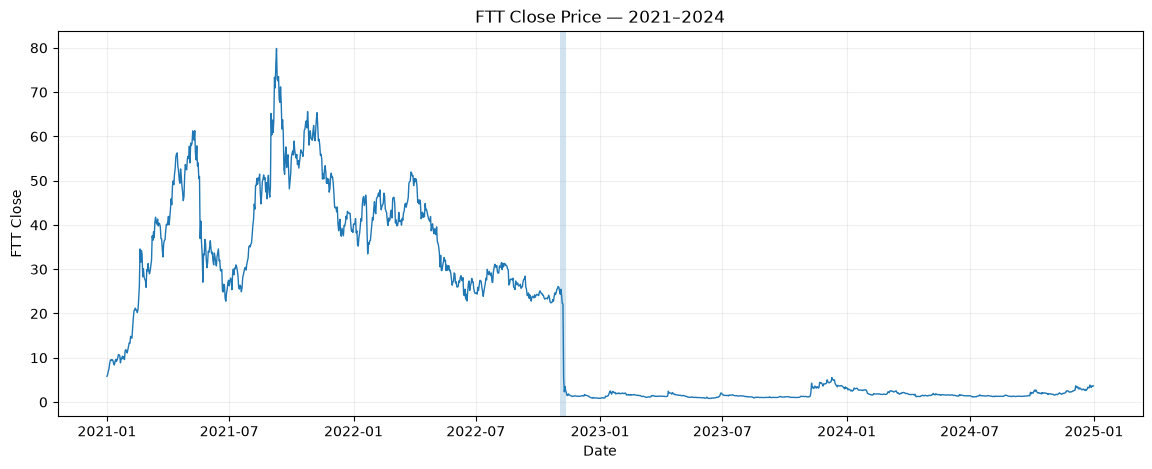

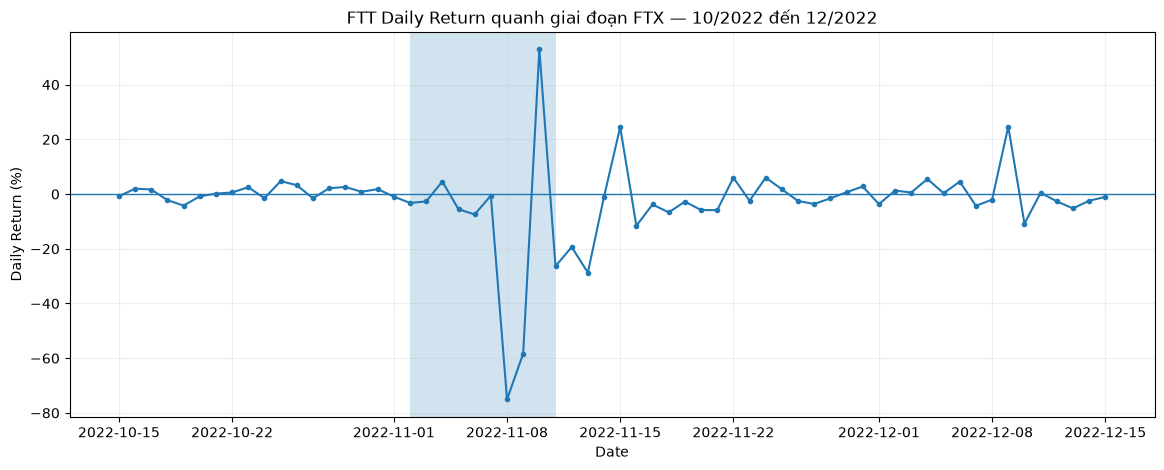

=== CÁC NGÀY BIẾN ĐỘNG MẠNH NHẤT QUANH EVENT ===


,Date,FTT_Close,Return
676,2022-11-08,5.518904,-75.075173
677,2022-11-09,2.300628,-58.313682
681,2022-11-13,1.489264,-28.705861
679,2022-11-11,2.590422,-26.344396
680,2022-11-12,2.088901,-19.360586
684,2022-11-16,1.623175,-11.587582
708,2022-12-10,1.516556,-10.819147
674,2022-11-06,22.269251,-7.440138
686,2022-11-18,1.457186,-6.691069
689,2022-11-21,1.255803,-5.884065


=== THỐNG KÊ PRE/EVENT/POST ===


,Period,Mean Return,Volatility (std),Min Return,Max Return,N
0,Pre-event,0.366226,5.387753,-27.510077,34.382538,669
1,Event 02–11/11/2022,-12.179270,35.225848,-75.075173,52.868610,10
2,Post-event,0.378191,8.833290,-28.705861,94.864293,781


In [13]:
# CELL 3 — Biến động giá và cú sốc FTX tháng 11/2022

event_start = pd.Timestamp('2022-10-15')
event_end = pd.Timestamp('2022-12-15')
event = ftt[(ftt['Date'] >= event_start) & (ftt['Date'] <= event_end)].copy()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ftt['Date'], ftt['FTT_Close'], linewidth=1)
ax.axvspan(pd.Timestamp('2022-11-02'), pd.Timestamp('2022-11-11'), alpha=0.2)
ax.set_title('FTT Close Price — 2021–2024')
ax.set_xlabel('Date')
ax.set_ylabel('FTT Close')
ax.grid(alpha=0.2)
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(event['Date'], event['Return'] * 100, marker='o', markersize=3)
ax.axhline(0, linewidth=1)
ax.axvspan(pd.Timestamp('2022-11-02'), pd.Timestamp('2022-11-11'), alpha=0.2)
ax.set_title('FTT Daily Return quanh giai đoạn FTX — 10/2022 đến 12/2022')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Return (%)')
ax.grid(alpha=0.2)
plt.show()

print('=== CÁC NGÀY BIẾN ĐỘNG MẠNH NHẤT QUANH EVENT ===')
display(
    event[['Date', 'FTT_Close', 'Return']]
    .sort_values('Return')
    .assign(Return=lambda x: x['Return'] * 100)
    .head(10)
)

print('=== THỐNG KÊ PRE/EVENT/POST ===')
pre = ftt[ftt['Date'] < '2022-11-02']['Return'].dropna()
during = ftt[(ftt['Date'] >= '2022-11-02') & (ftt['Date'] <= '2022-11-11')]['Return'].dropna()
post = ftt[ftt['Date'] > '2022-11-11']['Return'].dropna()

summary = pd.DataFrame({
    'Period': ['Pre-event', 'Event 02–11/11/2022', 'Post-event'],
    'Mean Return': [pre.mean(), during.mean(), post.mean()],
    'Volatility (std)': [pre.std(), during.std(), post.std()],
    'Min Return': [pre.min(), during.min(), post.min()],
    'Max Return': [pre.max(), during.max(), post.max()],
    'N': [len(pre), len(during), len(post)]
})
summary[['Mean Return', 'Volatility (std)', 'Min Return', 'Max Return']] *= 100
display(summary)

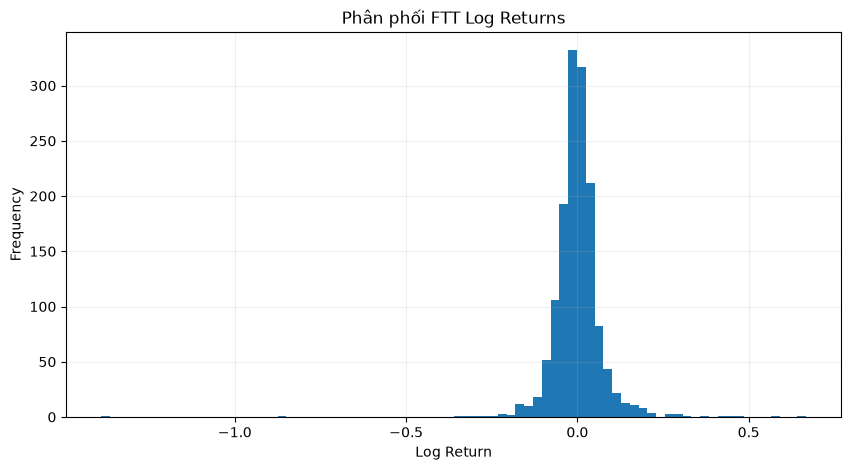

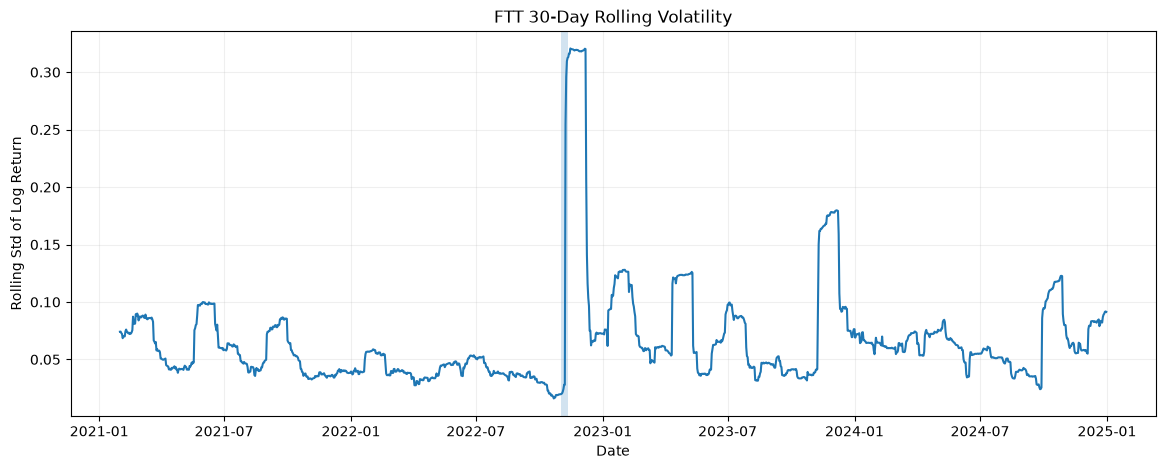

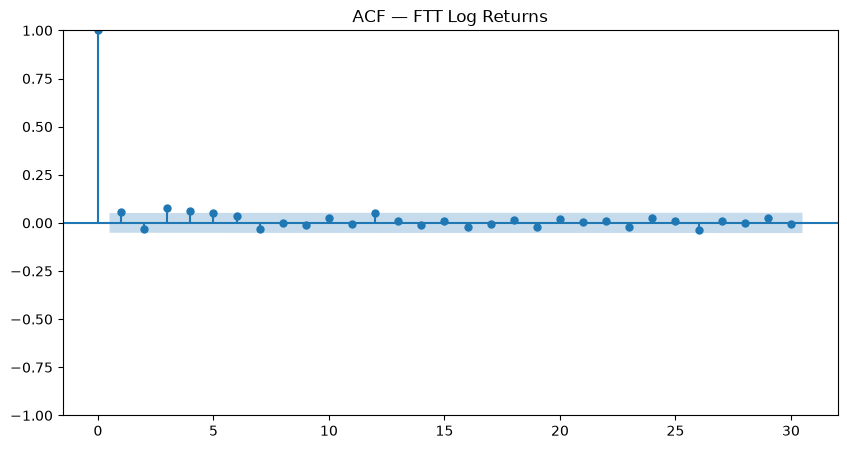

=== VOLATILITY ===
Volatility toàn kỳ: 0.0819
Volatility event: 0.3523
Tỷ lệ event/pre: 6.54x


In [14]:
# CELL 4 — Phân phối return + volatility rolling + ACF

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ftt['Log_Return'].dropna(), bins=80)
ax.set_title('Phân phối FTT Log Returns')
ax.set_xlabel('Log Return')
ax.set_ylabel('Frequency')
ax.grid(alpha=0.2)
plt.show()

# Rolling volatility 30 ngày
ftt['Rolling_Vol_30D'] = ftt['Log_Return'].rolling(30).std()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ftt['Date'], ftt['Rolling_Vol_30D'])
ax.axvspan(pd.Timestamp('2022-11-02'), pd.Timestamp('2022-11-11'), alpha=0.2)
ax.set_title('FTT 30-Day Rolling Volatility')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Std of Log Return')
ax.grid(alpha=0.2)
plt.show()

# ACF của log return
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(ftt['Log_Return'].dropna(), lags=30, ax=ax)
ax.set_title('ACF — FTT Log Returns')
plt.show()

print('=== VOLATILITY ===')
print('Volatility toàn kỳ:', f"{ftt['Log_Return'].std():.4f}")
print('Volatility event:', f"{during.std():.4f}")
print('Tỷ lệ event/pre:', f"{during.std() / pre.std():.2f}x")

In [15]:
# CELL 5 — ADF: kiểm tra stationarity của Price và Log Return

def adf_test(series, name):
    series = series.dropna()
    result = adfuller(series, autolag='AIC')
    statistic, pvalue, used_lag, nobs, critical_values, _ = result

    print(f'--- {name} ---')
    print(f'ADF statistic : {statistic:.4f}')
    print(f'p-value       : {pvalue:.6g}')
    print(f'Used lags     : {used_lag}')
    print(f'Observations  : {nobs}')
    print('Critical values:')
    for k, v in critical_values.items():
        print(f'  {k}: {v:.4f}')
    print('Kết luận ở mức 5%:', 'Stationary' if pvalue < 0.05 else 'Không bác bỏ H0 → chưa có bằng chứng đủ để kết luận stationary')
    print()

adf_test(ftt['FTT_Close'], 'FTT Price')
adf_test(np.log(ftt['FTT_Close']), 'FTT Log Price')
adf_test(ftt['Return'], 'FTT Simple Return')
adf_test(ftt['Log_Return'], 'FTT Log Return')

print('=== GỢI Ý ĐỌC KẾT QUẢ ===')
print('1. Nếu Price/Log Price không stationary nhưng Return/Log Return stationary → phù hợp với câu chuyện price non-stationarity.')
print('2. Nếu volatility tăng rất mạnh quanh 02–11/11/2022 → có bằng chứng mô tả tốt cho volatility shock.')
print('3. Nếu phân phối return có đuôi dày/outlier lớn → có thể khai thác insight về extreme movements.')
print('4. Nếu ACF return chủ yếu nhỏ nhưng rolling volatility có cụm tăng → có thể thảo luận volatility clustering, nhưng cần kiểm định bổ sung nếu muốn kết luận chặt chẽ.')

--- FTT Price ---
ADF statistic : -1.2219
p-value       : 0.664123
Used lags     : 17
Observations  : 1443
Critical values:
  1%: -3.4349
  5%: -2.8635
  10%: -2.5678
Kết luận ở mức 5%: Không bác bỏ H0 → chưa có bằng chứng đủ để kết luận stationary

--- FTT Log Price ---
ADF statistic : -1.1920
p-value       : 0.677012
Used lags     : 5
Observations  : 1455
Critical values:
  1%: -3.4349
  5%: -2.8635
  10%: -2.5678
Kết luận ở mức 5%: Không bác bỏ H0 → chưa có bằng chứng đủ để kết luận stationary



C:\Users\Le Nguyen My Duyen\AppData\Local\Temp\ipykernel_20176\3765434592.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series, autolag='AIC')
C:\Users\Le Nguyen My Duyen\AppData\Local\Temp\ipykernel_20176\3765434592.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series, autolag='AIC')
C:\Users\Le Nguyen My Duyen\AppData\Loca

--- FTT Simple Return ---
ADF statistic : -13.9243
p-value       : 5.22605e-26
Used lags     : 5
Observations  : 1454
Critical values:
  1%: -3.4349
  5%: -2.8635
  10%: -2.5678
Kết luận ở mức 5%: Stationary

--- FTT Log Return ---
ADF statistic : -14.8508
p-value       : 1.77861e-27
Used lags     : 4
Observations  : 1455
Critical values:
  1%: -3.4349
  5%: -2.8635
  10%: -2.5678
Kết luận ở mức 5%: Stationary

=== GỢI Ý ĐỌC KẾT QUẢ ===
1. Nếu Price/Log Price không stationary nhưng Return/Log Return stationary → phù hợp với câu chuyện price non-stationarity.
2. Nếu volatility tăng rất mạnh quanh 02–11/11/2022 → có bằng chứng mô tả tốt cho volatility shock.
3. Nếu phân phối return có đuôi dày/outlier lớn → có thể khai thác insight về extreme movements.
4. Nếu ACF return chủ yếu nhỏ nhưng rolling volatility có cụm tăng → có thể thảo luận volatility clustering, nhưng cần kiểm định bổ sung nếu muốn kết luận chặt chẽ.


C:\Users\Le Nguyen My Duyen\AppData\Local\Temp\ipykernel_20176\3765434592.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series, autolag='AIC')
